In [4]:
#노트북이 코랩에서 실행 중인지 체크합니다.

import sys
if 'google.colab' in sys.modules:
  !echo 'debconf debconf/frontend select Noniteractive' | \
  debconf-set-selections

  # 나눔 폰트를 설치합니다.
  !sudo apt-get -qq -y install fonts-nanum
  import matplotlib.font_manager as fm
  font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
  for fpath in font_files:
    fm.fontManager.addfont(fpath)

In [5]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['figure.dpi']=100

/tmp/ipython-input-2087538780.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)
/tmp/ipython-input-2087538780.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
/tmp/ipython-input-2087538780.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

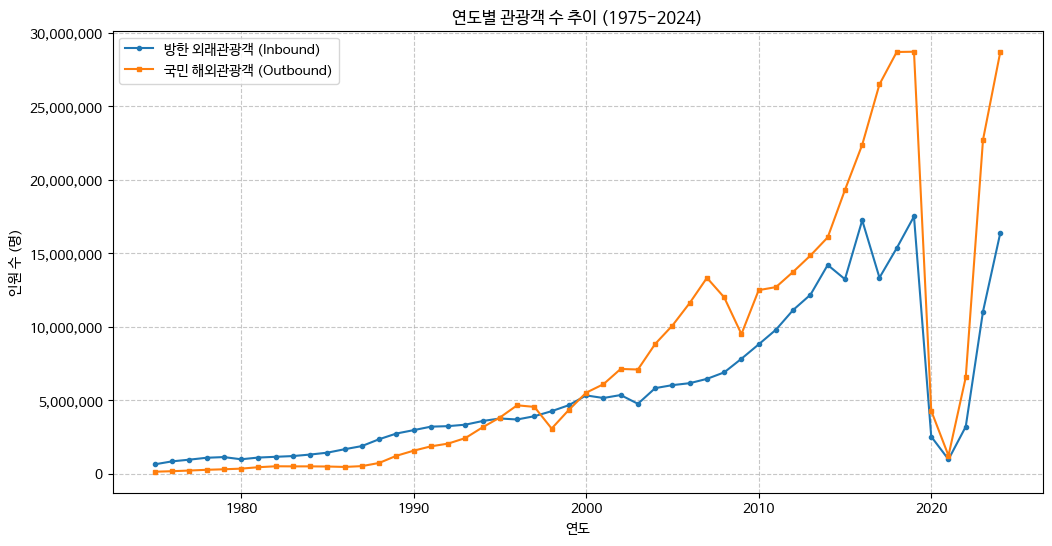

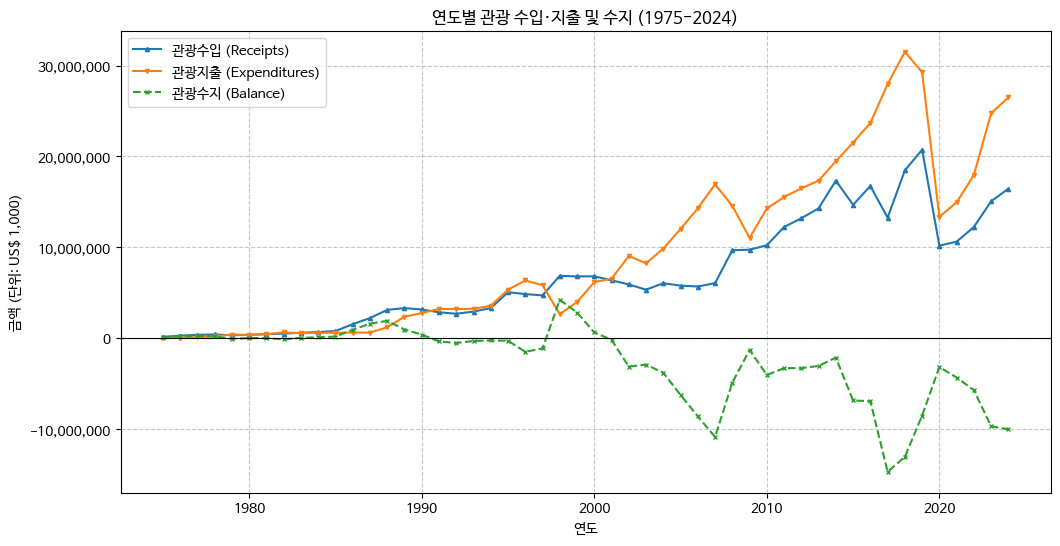

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 데이터 불러오기 (Excel 파일 읽기)
# 파일 경로 설정 (실제 파일 경로에 맞게 수정하세요)
file_path = '/content/연도별통계(1975-2024).xlsx'

# 각 시트(Sheet)별로 데이터 읽기
# sheet_name은 업로드해주신 CSV 파일명을 바탕으로 추정했습니다.
# 실제 엑셀 파일의 시트 이름이 다르다면 sheet_name='시트명' 부분을 수정해야 합니다.

# 방한 외래관광객 (헤더가 2번째 줄에 위치 -> header=1)
df_inbound = pd.read_excel(file_path, sheet_name='방한 외래관광객', header=1)
df_inbound = df_inbound[['Year', 'Total(명)']].copy()
df_inbound.columns = ['Year', 'Inbound']

# 국민 해외관광객 (헤더가 2번째 줄에 위치 -> header=1)
df_outbound = pd.read_excel(file_path, sheet_name='국민 해외관광객', header=1)
df_outbound = df_outbound[['Year', 'Total(명)']].copy()
df_outbound.columns = ['Year', 'Outbound']

# 관광수입 (헤더가 5번째 줄에 위치 -> header=4)
df_receipts = pd.read_excel(file_path, sheet_name='관광수입', header=4)
# 첫 번째(Year)와 두 번째(Total) 컬럼만 선택 (iloc 사용)
df_receipts = df_receipts.iloc[:, [0, 1]].copy()
df_receipts.columns = ['Year', 'Receipts']

# 관광지출 (헤더가 5번째 줄에 위치 -> header=4)
df_expenditures = pd.read_excel(file_path, sheet_name='관광지출', header=4)
df_expenditures = df_expenditures.iloc[:, [0, 1]].copy()
df_expenditures.columns = ['Year', 'Expenditures']

# 관광수지 (헤더가 5번째 줄에 위치 -> header=4)
df_balance = pd.read_excel(file_path, sheet_name='관광수지', header=4)
df_balance = df_balance.iloc[:, [0, 1]].copy()
df_balance.columns = ['Year', 'Balance']

# 2. 데이터 전처리 함수 (공통)
def clean_data(df, col_name):
    # 연도(Year)를 숫자로 변환 (문자열 등 변환 불가 값은 NaN 처리 후 제거)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df.dropna(subset=['Year'])
    df['Year'] = df['Year'].astype(int)

    # 데이터 값에 포함된 콤마(,) 제거 및 숫자 변환
    if df[col_name].dtype == 'object':
        df[col_name] = df[col_name].astype(str).str.replace(',', '', regex=False)
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
    return df

# 전처리 적용
df_inbound = clean_data(df_inbound, 'Inbound')
df_outbound = clean_data(df_outbound, 'Outbound')
df_receipts = clean_data(df_receipts, 'Receipts')
df_expenditures = clean_data(df_expenditures, 'Expenditures')
df_balance = clean_data(df_balance, 'Balance')

# 데이터 병합 (연도 기준 Outer Join)
df_merged = df_inbound.merge(df_outbound, on='Year', how='outer') \
                      .merge(df_receipts, on='Year', how='outer') \
                      .merge(df_expenditures, on='Year', how='outer') \
                      .merge(df_balance, on='Year', how='outer')
df_merged = df_merged.sort_values('Year')

# 3. 시각화 (한글 폰트 설정 필요)
# 운영체제에 맞는 한글 폰트로 변경해주세요 (예: 'Malgun Gothic', 'AppleGothic' 등)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 1: 관광객 수 추이
plt.figure(figsize=(12, 6))
plt.plot(df_merged['Year'], df_merged['Inbound'], label='방한 외래관광객 (Inbound)', marker='o', markersize=3)
plt.plot(df_merged['Year'], df_merged['Outbound'], label='국민 해외관광객 (Outbound)', marker='s', markersize=3)
plt.title('연도별 관광객 수 추이 (1975-2024)')
plt.xlabel('연도')
plt.ylabel('인원 수 (명)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()

# 그래프 2: 관광 수입·지출 및 수지
plt.figure(figsize=(12, 6))
plt.plot(df_merged['Year'], df_merged['Receipts'], label='관광수입 (Receipts)', marker='^', markersize=3)
plt.plot(df_merged['Year'], df_merged['Expenditures'], label='관광지출 (Expenditures)', marker='v', markersize=3)
plt.plot(df_merged['Year'], df_merged['Balance'], label='관광수지 (Balance)', marker='x', markersize=3, linestyle='--')
plt.axhline(0, color='black', linewidth=0.8) # 0 기준선
plt.title('연도별 관광 수입·지출 및 수지 (1975-2024)')
plt.xlabel('연도')
plt.ylabel('금액 (단위: US$ 1,000)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.show()